<a href="https://colab.research.google.com/github/prometricas/William_Rondon/blob/main/William_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **PSP: Análisis estadístico del instrumento**
* **Autor**: William Rondon
---





# **1. Importar datasents**

In [1]:
import numpy as np
import pandas as pd
from google.colab import files

# =========================================================
# 1) Subir archivos
# =========================================================
uploaded = files.upload()

def find_uploaded_file(uploaded_dict, required_tokens):
    keys = list(uploaded_dict.keys())
    for k in keys:
        low = k.lower()
        if all(tok.lower() in low for tok in required_tokens):
            return k
    raise FileNotFoundError(f"No encontré un archivo que contenga: {required_tokens}")

file_pilot = find_uploaded_file(uploaded, ["psp", "piloto", "1102"])
file_exp   = find_uploaded_file(uploaded, ["psp", "experimental", "1003"])
file_ctrl  = find_uploaded_file(uploaded, ["psp", "control", "1004"])

# =========================================================
# 2) Funciones para extraer dataframes
# =========================================================
ITEM_COLS = [f"i{i:02d}" for i in range(1, 16)]
PATTERN_COLS = [f"patron_{i:02d}" for i in range(1, 16)]

DIMENSIONES_PSP = {
    "D1_Concepto_Elemento_Quimico": ["i01", "i02", "i03"],
    "D2_Ordenamiento_SP": ["i04", "i05", "i06"],
    "D3_Periodicidad_Quimica": ["i07", "i08", "i09"],
    "D4_Estructura_Atomica_y_SP": ["i10", "i11", "i12"],
    "D5_NDC_y_SP": ["i13", "i14", "i15"],
}

def extract_psp_pilot(file_path):
    """
    Extrae el piloto desde la hoja TOTAL.
    No hay hoja Estudiantes en este libro, así que sexo/edad quedan vacíos.
    """
    total = pd.read_excel(file_path, sheet_name="TOTAL", header=None)

    # Desde fila 5 en adelante están estudiantes + algunas filas basura al final
    data = total.iloc[4:].copy()

    # Filtrar solo filas cuyo nombre de estudiante sea texto real
    mask_students = data.iloc[:, 1].apply(
        lambda x: isinstance(x, str) and x.strip() not in ["", "Total Est"]
    )
    data = data[mask_students].copy().reset_index(drop=True)

    df = pd.DataFrame({
        "codigo": [f"PIL_{i:02d}" for i in range(1, len(data) + 1)],
        "nombre": data.iloc[:, 1].astype(str).str.strip(),
        "sexo": pd.NA,
        "edad": pd.NA,
        "grupo": "piloto",
        "momento": "piloto",
    })

    # Puntajes y patrones por ítem
    for i in range(1, 16):
        score_col = 2 + (2 * i - 1)   # I1 score en col 3, I2 score en col 5, etc.
        patt_col  = score_col + 1

        df[f"i{i:02d}"] = pd.to_numeric(data.iloc[:, score_col], errors="coerce")
        df[f"patron_{i:02d}"] = data.iloc[:, patt_col].replace({np.nan: pd.NA})

    # Resumen del TOTAL
    df["total"] = pd.to_numeric(data.iloc[:, 33], errors="coerce")
    df["rendimiento"] = pd.to_numeric(data.iloc[:, 34], errors="coerce")
    df["n_correcto"] = pd.to_numeric(data.iloc[:, 35], errors="coerce")
    df["prop_correcto"] = pd.to_numeric(data.iloc[:, 36], errors="coerce")
    df["n_falso_pos"] = pd.to_numeric(data.iloc[:, 37], errors="coerce")
    df["prop_falso_pos"] = pd.to_numeric(data.iloc[:, 38], errors="coerce")
    df["n_raz_emerg"] = pd.to_numeric(data.iloc[:, 39], errors="coerce")
    df["prop_raz_emerg"] = pd.to_numeric(data.iloc[:, 40], errors="coerce")
    df["n_incorrecto"] = pd.to_numeric(data.iloc[:, 41], errors="coerce")
    df["prop_incorrecto"] = pd.to_numeric(data.iloc[:, 42], errors="coerce")
    df["calificacion"] = pd.to_numeric(data.iloc[:, 43], errors="coerce")

    return df


def extract_psp_pretest(file_path, group="experimental", absent_codes=None):
    """
    Extrae experimental o control desde:
    - Estudiantes
    - TOTAL Est
    """
    total = pd.read_excel(file_path, sheet_name="TOTAL Est", header=None)
    est = pd.read_excel(file_path, sheet_name="Estudiantes", header=None)

    # -----------------------------
    # TOTAL Est
    # -----------------------------
    data = total.iloc[4:].copy()
    data = data[data.iloc[:, 1].astype(str).str.startswith("Est ", na=False)].copy()
    data = data.reset_index(drop=True)

    score_block = pd.DataFrame({
        "codigo": data.iloc[:, 1].astype(str).str.strip(),
        "nombre_total": data.iloc[:, 2].astype(str).str.strip(),
    })

    for i in range(1, 16):
        score_col = 2 + (2 * i - 1)
        patt_col  = score_col + 1

        score_block[f"i{i:02d}"] = pd.to_numeric(data.iloc[:, score_col], errors="coerce")
        score_block[f"patron_{i:02d}"] = data.iloc[:, patt_col].replace({np.nan: pd.NA})

    score_block["total"] = pd.to_numeric(data.iloc[:, 33], errors="coerce")
    score_block["rendimiento"] = pd.to_numeric(data.iloc[:, 34], errors="coerce")
    score_block["n_correcto"] = pd.to_numeric(data.iloc[:, 35], errors="coerce")
    score_block["prop_correcto"] = pd.to_numeric(data.iloc[:, 36], errors="coerce")
    score_block["n_falso_pos"] = pd.to_numeric(data.iloc[:, 37], errors="coerce")
    score_block["prop_falso_pos"] = pd.to_numeric(data.iloc[:, 38], errors="coerce")
    score_block["n_raz_emerg"] = pd.to_numeric(data.iloc[:, 39], errors="coerce")
    score_block["prop_raz_emerg"] = pd.to_numeric(data.iloc[:, 40], errors="coerce")
    score_block["n_incorrecto"] = pd.to_numeric(data.iloc[:, 41], errors="coerce")
    score_block["prop_incorrecto"] = pd.to_numeric(data.iloc[:, 42], errors="coerce")
    score_block["calificacion"] = pd.to_numeric(data.iloc[:, 43], errors="coerce")

    # -----------------------------
    # Roster desde Estudiantes
    # -----------------------------
    if group.lower().startswith("exp"):
        roster = est.iloc[2:, [0, 1, 2, 3]].copy()
    else:
        # siempre tomo las últimas 4 columnas, así sirve aunque el libro tenga 9 o 10 columnas
        roster = est.iloc[2:, [-4, -3, -2, -1]].copy()

    roster.columns = ["codigo", "nombre", "sexo", "edad"]
    roster = roster[roster["codigo"].astype(str).str.startswith("Est ", na=False)].copy()

    roster["codigo"] = roster["codigo"].astype(str).str.strip()
    roster["nombre"] = roster["nombre"].astype(str).str.strip()
    roster["sexo"] = roster["sexo"].astype(str).str.strip()
    roster["edad"] = pd.to_numeric(roster["edad"], errors="coerce")

    if absent_codes:
        roster = roster[~roster["codigo"].isin(absent_codes)].copy()

    # Merge
    df = roster.merge(score_block.drop(columns=["nombre_total"]), on="codigo", how="inner")
    df.insert(4, "grupo", "experimental" if group.lower().startswith("exp") else "control")
    df.insert(5, "momento", "pretest")

    return df


# =========================================================
# 3) Crear dataframes base
# =========================================================
df_psp_piloto = extract_psp_pilot(file_pilot)
df_psp_exp = extract_psp_pretest(file_exp, group="experimental")
df_psp_ctrl = extract_psp_pretest(file_ctrl, group="control")

# Dataframe combinado pretest
df_psp_pre = pd.concat([df_psp_exp, df_psp_ctrl], ignore_index=True)

# =========================================================
# 4) Validación rápida
# =========================================================
print("df_psp_piloto:", df_psp_piloto.shape)
print("df_psp_exp   :", df_psp_exp.shape)
print("df_psp_ctrl  :", df_psp_ctrl.shape)
print("df_psp_pre   :", df_psp_pre.shape)

display(df_psp_piloto.head())
display(df_psp_exp.head())
display(df_psp_ctrl.head())

Saving PSP Piloto 1102.xlsx to PSP Piloto 1102.xlsx
Saving PSP Pre Test CONTROL 1004.xlsx to PSP Pre Test CONTROL 1004.xlsx
Saving PSP Pre Test EXPERIMENTAL 1003.xlsx to PSP Pre Test EXPERIMENTAL 1003.xlsx
df_psp_piloto: (28, 47)
df_psp_exp   : (31, 47)
df_psp_ctrl  : (28, 47)
df_psp_pre   : (59, 47)


,codigo,nombre,sexo,edad,grupo,momento,i01,patron_01,i02,patron_02,...,rendimiento,n_correcto,prop_correcto,n_falso_pos,prop_falso_pos,n_raz_emerg,prop_raz_emerg,n_incorrecto,prop_incorrecto,calificacion
0,PIL_01,Cortes Gabriela,<NA>,<NA>,piloto,piloto,0,Incorrecto,1,Razonamiento Emergente,...,0.466667,4,0.266667,4,0.266667,2,0.133333,5,0.333333,2.333333
1,PIL_02,Juan Posada,<NA>,<NA>,piloto,piloto,2,Correcto,0,Incorrecto,...,0.400000,2,0.133333,5,0.333333,3,0.200000,5,0.333333,2.000000
2,PIL_03,Hugo Fajardo,<NA>,<NA>,piloto,piloto,2,Correcto,1,Razonamiento Emergente,...,0.466667,4,0.266667,3,0.200000,3,0.200000,5,0.333333,2.333333
3,PIL_04,NN,<NA>,<NA>,piloto,piloto,1,Razonamiento Emergente,0,Incorrecto,...,0.300000,1,0.066667,3,0.200000,4,0.266667,7,0.466667,1.500000
4,PIL_05,Yoshira Florez,<NA>,<NA>,piloto,piloto,0,Incorrecto,1,Falso +,...,0.233333,1,0.066667,3,0.200000,2,0.133333,9,0.600000,1.166667


,codigo,nombre,sexo,edad,grupo,momento,i01,patron_01,i02,patron_02,...,rendimiento,n_correcto,prop_correcto,n_falso_pos,prop_falso_pos,n_raz_emerg,prop_raz_emerg,n_incorrecto,prop_incorrecto,calificacion
0,Est 1,Owen Martínez,M,15,experimental,pretest,0,Incorrecto,0,Incorrecto,...,0.266667,1,0.066667,4,0.266667,2,0.133333,8,0.533333,1.333333
1,Est 2,Maria Lucia Jimenez,F,15,experimental,pretest,2,Correcto,0,Incorrecto,...,0.266667,1,0.066667,5,0.333333,1,0.066667,8,0.533333,1.333333
2,Est 3,Juan David Pilonieta,M,15,experimental,pretest,2,Correcto,2,Correcto,...,0.566667,6,0.400000,1,0.066667,4,0.266667,4,0.266667,2.833333
3,Est 4,Jose Bolivar,M,16,experimental,pretest,1,Falso +,2,Correcto,...,0.466667,5,0.333333,3,0.200000,1,0.066667,6,0.400000,2.333333
4,Est 5,Dilan Porras,M,15,experimental,pretest,1,Razonamiento Emergente,0,Incorrecto,...,0.333333,2,0.133333,3,0.200000,3,0.200000,7,0.466667,1.666667


,codigo,nombre,sexo,edad,grupo,momento,i01,patron_01,i02,patron_02,...,rendimiento,n_correcto,prop_correcto,n_falso_pos,prop_falso_pos,n_raz_emerg,prop_raz_emerg,n_incorrecto,prop_incorrecto,calificacion
0,Est 1,Hanna Guarumo,F,16,control,pretest,0,Incorrecto,2,Correcto,...,0.266667,2,0.133333,2,0.133333,2,0.133333,9,0.600000,1.333333
1,Est 2,Ana Mileth Collo Valencia,F,16,control,pretest,0,Incorrecto,1,Falso +,...,0.300000,0,0.000000,6,0.400000,3,0.200000,6,0.400000,1.500000
2,Est 3,Pineda Caro Liz,F,15,control,pretest,2,Correcto,2,Correcto,...,0.833333,11,0.733333,0,0.000000,3,0.200000,1,0.066667,4.166667
3,Est 4,Anny Jireth Cabrera Calderon,F,17,control,pretest,2,Correcto,0,Incorrecto,...,0.266667,3,0.200000,1,0.066667,1,0.066667,10,0.666667,1.333333
4,Est 5,Isabella Victorino Nuñez,F,15,control,pretest,2,Correcto,1,Falso +,...,0.600000,8,0.533333,1,0.066667,1,0.066667,5,0.333333,3.000000


# **2. Confiabilidad apropiada para escala politómica ordinal**

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# =========================================================
# 1) Utilidades matemáticas
# =========================================================
def nearest_psd_corr(R, eps=1e-6):
    """
    Corrige una matriz para que sea semidefinida positiva.
    """
    R = np.array(R, dtype=float)
    R = (R + R.T) / 2
    np.fill_diagonal(R, 1.0)

    vals, vecs = np.linalg.eigh(R)
    vals[vals < eps] = eps
    R_psd = vecs @ np.diag(vals) @ vecs.T

    d = np.sqrt(np.diag(R_psd))
    R_psd = R_psd / np.outer(d, d)
    np.fill_diagonal(R_psd, 1.0)
    return R_psd


def gaussian_rank_transform(df):
    """
    Aproximación ordinal estable:
    transforma cada variable ordinal a puntajes normales por rangos.
    """
    X = df.copy().apply(pd.to_numeric, errors="coerce")
    Z = pd.DataFrame(index=X.index, columns=X.columns, dtype=float)

    for col in X.columns:
        s = X[col]
        mask = s.notna()
        n = mask.sum()

        if n < 3:
            continue

        ranks = s[mask].rank(method="average")
        u = (ranks - 0.5) / n
        u = np.clip(u, 1e-6, 1 - 1e-6)
        Z.loc[mask, col] = norm.ppf(u)

    return Z


def ordinal_corr_matrix(df):
    """
    Matriz de correlación ordinal aproximada.
    """
    X = df.copy().apply(pd.to_numeric, errors="coerce")

    keep = [c for c in X.columns if X[c].notna().sum() >= 5 and X[c].nunique(dropna=True) > 1]
    X = X[keep].copy()

    if X.shape[1] < 2:
        return pd.DataFrame()

    Z = gaussian_rank_transform(X)
    R = Z.corr(method="pearson", min_periods=max(5, int(0.70 * len(Z))))

    if R.empty:
        return pd.DataFrame()

    R = pd.DataFrame(nearest_psd_corr(R.values), index=R.index, columns=R.columns)
    return R


def cronbach_alpha(df):
    X = df.copy().apply(pd.to_numeric, errors="coerce").dropna(axis=0, how="any")
    k = X.shape[1]

    if k < 2 or len(X) < 2:
        return np.nan

    item_vars = X.var(axis=0, ddof=1)
    total_var = X.sum(axis=1).var(ddof=1)

    if total_var <= 0:
        return np.nan

    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)


def alpha_from_corr(R):
    if isinstance(R, pd.DataFrame):
        R = R.values

    R = np.array(R, dtype=float)
    k = R.shape[0]

    if k < 2:
        return np.nan

    return (k / (k - 1)) * (1 - (k / R.sum()))


def omega_from_corr(R):
    if isinstance(R, pd.DataFrame):
        R = R.values

    R = np.array(R, dtype=float)
    k = R.shape[0]

    if k < 2:
        return np.nan

    vals, vecs = np.linalg.eigh(R)
    idx = np.argmax(vals)

    lam1 = vals[idx]
    vec1 = vecs[:, idx]
    loadings = np.sqrt(max(lam1, 0)) * vec1

    uniq = 1 - loadings**2
    uniq[uniq < 1e-6] = 1e-6

    num = (loadings.sum())**2
    den = num + uniq.sum()

    return num / den if den > 0 else np.nan


def omega_classic_scores(df):
    X = df.copy().apply(pd.to_numeric, errors="coerce").dropna(axis=0, how="any")

    if X.shape[1] < 2 or len(X) < 5:
        return np.nan

    R = X.corr().values
    R = nearest_psd_corr(R)

    return omega_from_corr(R)


def split_half_spearman_brown(df):
    X = df.copy().apply(pd.to_numeric, errors="coerce").dropna(axis=0, how="any")

    if X.shape[1] < 2 or len(X) < 3:
        return np.nan, np.nan

    cols1 = X.columns[::2]
    cols2 = X.columns[1::2]

    if len(cols1) == 0 or len(cols2) == 0:
        return np.nan, np.nan

    s1 = X[cols1].mean(axis=1)
    s2 = X[cols2].mean(axis=1)

    r = s1.corr(s2)
    sb = (2 * r) / (1 + r) if pd.notna(r) and (1 + r) != 0 else np.nan

    return r, sb


# =========================================================
# 2) Función principal de análisis
# =========================================================
def analizar_psp_confiabilidad(df, label):
    X = df[ITEM_COLS].copy().apply(pd.to_numeric, errors="coerce")

    # ---------- total ----------
    R_ord = ordinal_corr_matrix(X)
    r_split, sb = split_half_spearman_brown(X)

    tabla_total = pd.DataFrame([{
        "muestra": label,
        "n": len(df),
        "alpha_clasico": cronbach_alpha(X),
        "omega_clasico": omega_classic_scores(X),
        "alpha_ordinal": alpha_from_corr(R_ord),
        "omega_ordinal": omega_from_corr(R_ord),
        "split_half_r": r_split,
        "spearman_brown": sb,
    }]).round(4)

    # ---------- por dimensión ----------
    rows_dim = []
    for dim, cols in DIMENSIONES_PSP.items():
        sub = X[cols].copy()
        R_dim = ordinal_corr_matrix(sub)

        rows_dim.append({
            "muestra": label,
            "dimension": dim,
            "n_items": len(cols),
            "alpha_clasico": cronbach_alpha(sub),
            "alpha_ordinal": alpha_from_corr(R_dim),
            "omega_ordinal": omega_from_corr(R_dim),
        })

    tabla_dim = pd.DataFrame(rows_dim).round(4)

    # ---------- diagnóstico por ítem ----------
    X_ord = gaussian_rank_transform(X)
    rows_item = []

    for col in ITEM_COLS:
        resto = X_ord.drop(columns=[col]).mean(axis=1)
        rit = X_ord[col].corr(resto)

        R_drop = ordinal_corr_matrix(X.drop(columns=[col]))

        rows_item.append({
            "muestra": label,
            "item": col,
            "media_item": X[col].mean(),
            "rit_ordinal": rit,
            "alpha_ordinal_si_se_elimina": alpha_from_corr(R_drop),
        })

    tabla_item = pd.DataFrame(rows_item).round(4)

    return {
        "total": tabla_total,
        "dimensiones": tabla_dim,
        "items": tabla_item,
        "R_ordinal": R_ord,
    }


# =========================================================
# 3) Ejecutar análisis sobre todas las muestras
# =========================================================
resultados_psp = {
    "Piloto": analizar_psp_confiabilidad(df_psp_piloto, "Piloto"),
    "Experimental": analizar_psp_confiabilidad(df_psp_exp, "Experimental"),
    "Control": analizar_psp_confiabilidad(df_psp_ctrl, "Control"),
    "Pretest combinado": analizar_psp_confiabilidad(df_psp_pre, "Pretest combinado"),
}

psp_total = pd.concat([v["total"] for v in resultados_psp.values()], ignore_index=True)
psp_dim = pd.concat([v["dimensiones"] for v in resultados_psp.values()], ignore_index=True)
psp_items = pd.concat([v["items"] for v in resultados_psp.values()], ignore_index=True)

print("=== Confiabilidad total PSP ===")
display(psp_total)

print("\n=== Confiabilidad por dimensión PSP ===")
display(psp_dim)

print("\n=== Diagnóstico por ítem PSP ===")
display(psp_items)

=== Confiabilidad total PSP ===


,muestra,n,alpha_clasico,omega_clasico,alpha_ordinal,omega_ordinal,split_half_r,spearman_brown
0,Piloto,28,0.3187,0.1434,0.2678,0.1305,0.1220,0.2175
1,Experimental,31,0.6145,0.7022,0.5910,0.6929,0.5066,0.6725
2,Control,28,0.8229,0.8605,0.8219,0.8586,0.5747,0.7299
3,Pretest combinado,59,0.7627,0.8158,0.7524,0.8108,0.5636,0.7209



=== Confiabilidad por dimensión PSP ===


,muestra,dimension,n_items,alpha_clasico,alpha_ordinal,omega_ordinal
0,Piloto,D1_Concepto_Elemento_Quimico,3,0.1754,0.1256,0.5062
1,Piloto,D2_Ordenamiento_SP,3,-0.0517,-0.0567,0.1863
2,Piloto,D3_Periodicidad_Quimica,3,0.1250,0.0991,0.4535
3,Piloto,D4_Estructura_Atomica_y_SP,3,0.2228,0.2083,0.5174
4,Piloto,D5_NDC_y_SP,3,0.0115,-0.0163,0.0735
5,Experimental,D1_Concepto_Elemento_Quimico,3,0.4085,0.4100,0.7147
6,Experimental,D2_Ordenamiento_SP,3,0.0713,0.1146,0.4322
7,Experimental,D3_Periodicidad_Quimica,3,-0.3794,-0.3628,0.0245
8,Experimental,D4_Estructura_Atomica_y_SP,3,-0.2452,-0.2343,0.1249
9,Experimental,D5_NDC_y_SP,3,0.3440,0.3412,0.6935



=== Diagnóstico por ítem PSP ===


,muestra,item,media_item,rit_ordinal,alpha_ordinal_si_se_elimina
0,Piloto,i01,1.2143,0.1806,0.2134
1,Piloto,i02,1.0714,0.1425,0.2319
2,Piloto,i03,1.3571,0.0385,0.2719
3,Piloto,i04,0.8571,-0.0248,0.2917
4,Piloto,i05,1.2857,0.1350,0.2345
5,Piloto,i06,0.7143,-0.0497,0.3006
6,Piloto,i07,0.6786,0.1884,0.2147
7,Piloto,i08,0.5357,0.1594,0.2238
8,Piloto,i09,0.2143,0.0260,0.2754
9,Piloto,i10,0.5714,0.1721,0.2259


# **3. Análisis gráfico**

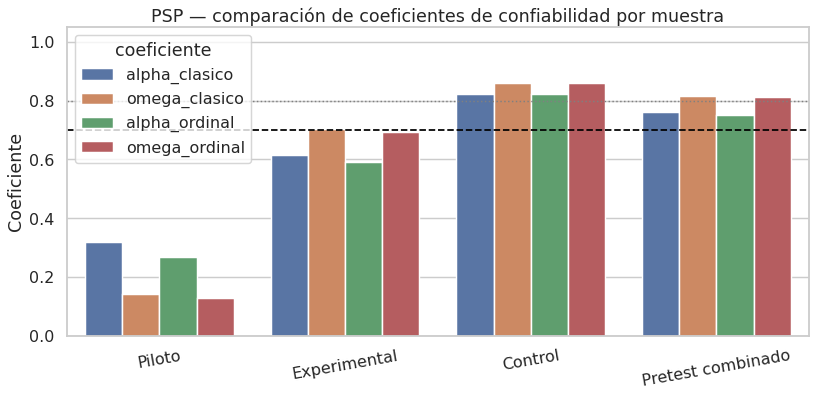

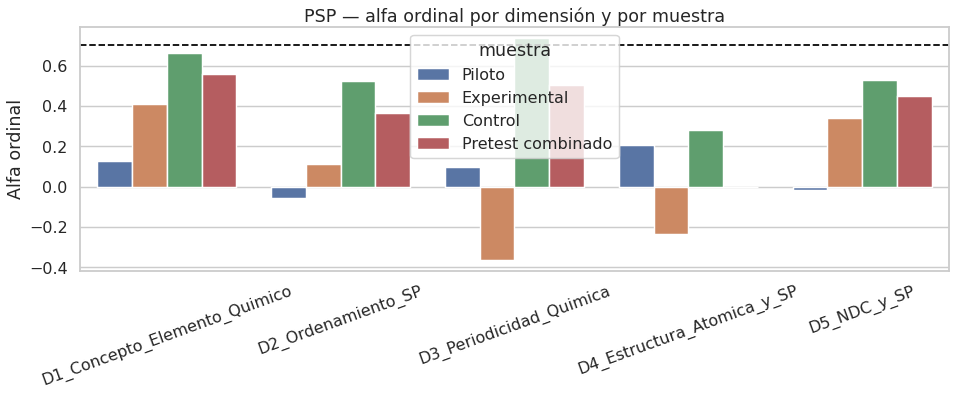

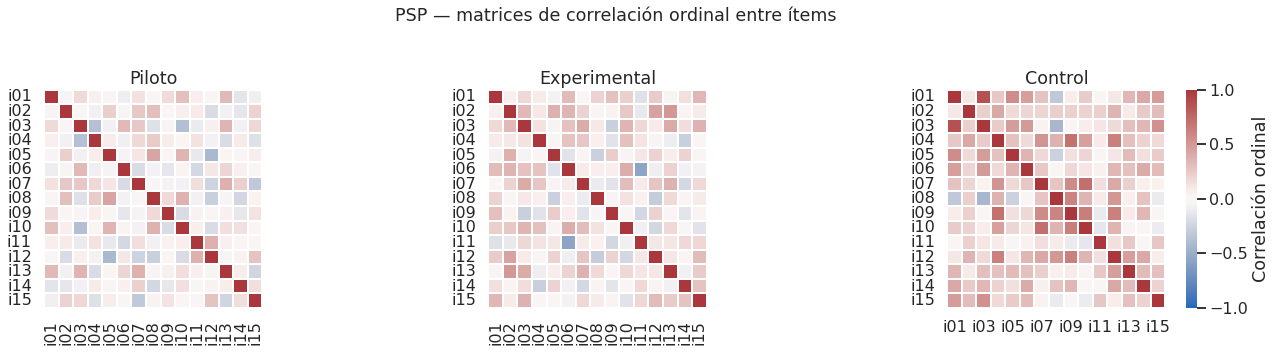

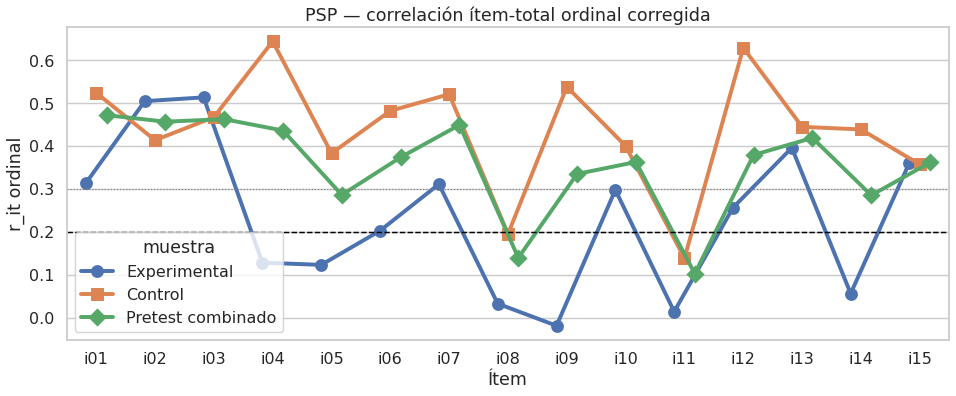

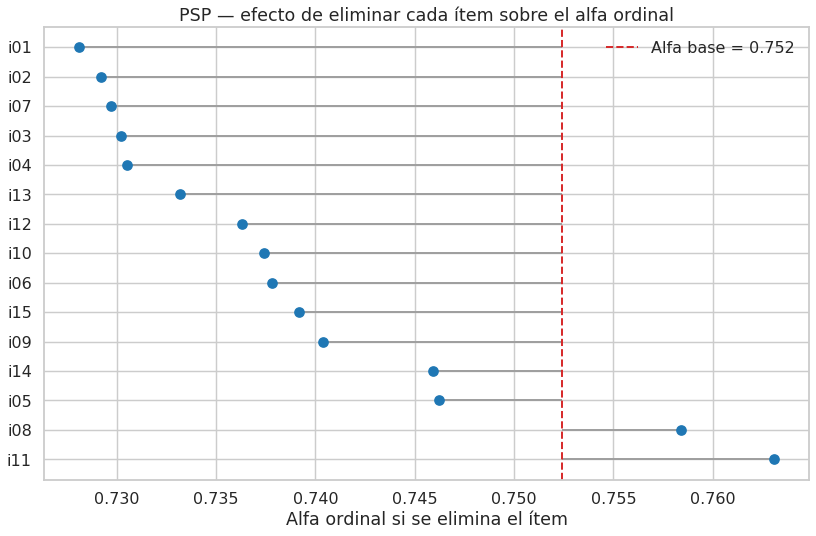

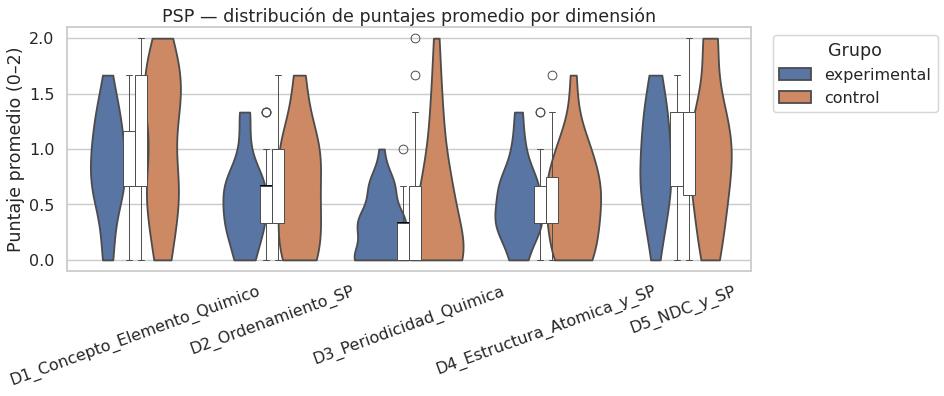

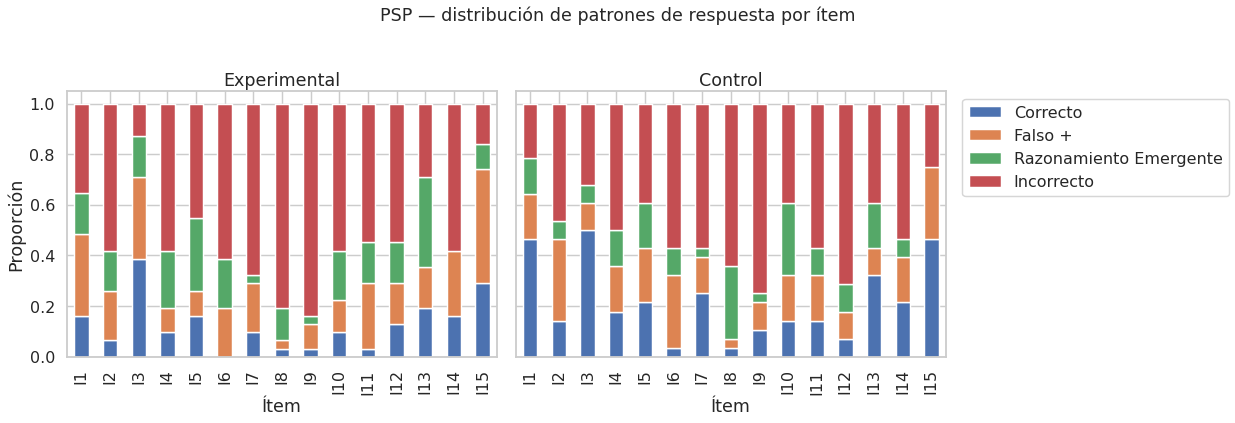

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 70

# =========================================================
# 1) Barras comparativas: confiabilidad total
# =========================================================
plot_total = psp_total.melt(
    id_vars=["muestra", "n"],
    value_vars=["alpha_clasico", "omega_clasico", "alpha_ordinal", "omega_ordinal"],
    var_name="coeficiente",
    value_name="valor"
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=plot_total,
    x="muestra",
    y="valor",
    hue="coeficiente"
)
ax.axhline(0.70, color="black", linestyle="--", linewidth=1.8)
ax.axhline(0.80, color="gray", linestyle=":", linewidth=1.5)
ax.set_title("PSP — comparación de coeficientes de confiabilidad por muestra")
ax.set_xlabel("")
ax.set_ylabel("Coeficiente")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# =========================================================
# 2) Barras comparativas: alfa ordinal por dimensión
# =========================================================
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=psp_dim,
    x="dimension",
    y="alpha_ordinal",
    hue="muestra"
)
ax.axhline(0.70, color="black", linestyle="--", linewidth=1.8)
ax.set_title("PSP — alfa ordinal por dimensión y por muestra")
ax.set_xlabel("")
ax.set_ylabel("Alfa ordinal")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# =========================================================
# 3) Heatmaps de correlación ordinal entre ítems
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, label in zip(axes, ["Piloto", "Experimental", "Control"]):
    R = resultados_psp[label]["R_ordinal"].copy()

    sns.heatmap(
        R,
        ax=ax,
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.4,
        cbar=(label == "Control"),
        cbar_kws={"label": "Correlación ordinal"} if label == "Control" else None
    )
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("PSP — matrices de correlación ordinal entre ítems", y=1.02, fontsize=18)
plt.tight_layout()
plt.show()

# =========================================================
# 4) Comparación de r_it ordinal por ítem
# =========================================================
plot_items = psp_items[
    psp_items["muestra"].isin(["Experimental", "Control", "Pretest combinado"])
].copy()

plt.figure(figsize=(14, 6))
ax = sns.pointplot(
    data=plot_items,
    x="item",
    y="rit_ordinal",
    hue="muestra",
    dodge=0.35,
    markers=["o", "s", "D"],
    linestyles="-"
)
ax.axhline(0.20, color="black", linestyle="--", linewidth=1.5)
ax.axhline(0.30, color="gray", linestyle=":", linewidth=1.2)
ax.set_title("PSP — correlación ítem-total ordinal corregida")
ax.set_xlabel("Ítem")
ax.set_ylabel("r_it ordinal")
plt.tight_layout()
plt.show()

# =========================================================
# 5) Lollipop: alfa ordinal si se elimina el ítem
#    (sobre pretest combinado)
# =========================================================
base_alpha = float(
    psp_total.loc[psp_total["muestra"] == "Pretest combinado", "alpha_ordinal"].iloc[0]
)

plot_drop = psp_items[psp_items["muestra"] == "Pretest combinado"].copy()
plot_drop = plot_drop.sort_values("alpha_ordinal_si_se_elimina", ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 8))
y = np.arange(len(plot_drop))

plt.hlines(
    y=y,
    xmin=base_alpha,
    xmax=plot_drop["alpha_ordinal_si_se_elimina"],
    color="#9E9E9E",
    linewidth=2
)

plt.scatter(
    plot_drop["alpha_ordinal_si_se_elimina"],
    y,
    s=90,
    color="#1f77b4",
    zorder=3
)

plt.axvline(base_alpha, color="#d62728", linestyle="--", linewidth=2, label=f"Alfa base = {base_alpha:.3f}")
plt.yticks(y, plot_drop["item"])
plt.xlabel("Alfa ordinal si se elimina el ítem")
plt.ylabel("")
plt.title("PSP — efecto de eliminar cada ítem sobre el alfa ordinal")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# =========================================================
# 6) Distribución de puntajes por dimensión
#    (comparación experimental vs control)
# =========================================================
df_plot_dim = df_psp_pre.copy()

for dim, cols in DIMENSIONES_PSP.items():
    df_plot_dim[dim] = df_plot_dim[cols].mean(axis=1)

long_dim = df_plot_dim.melt(
    id_vars=["grupo"],
    value_vars=list(DIMENSIONES_PSP.keys()),
    var_name="dimension",
    value_name="puntaje_dim"
)

plt.figure(figsize=(14, 6))
ax = sns.violinplot(
    data=long_dim,
    x="dimension",
    y="puntaje_dim",
    hue="grupo",
    cut=0,
    inner=None
)
sns.boxplot(
    data=long_dim,
    x="dimension",
    y="puntaje_dim",
    hue="grupo",
    width=0.18,
    dodge=True,
    boxprops={"facecolor": "white", "zorder": 3},
    medianprops={"color": "black", "linewidth": 2}
)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Grupo", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.title("PSP — distribución de puntajes promedio por dimensión")
plt.xlabel("")
plt.ylabel("Puntaje promedio (0–2)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# =========================================================
# 7) Distribución de patrones por ítem y grupo
# =========================================================
def patterns_long(df):
    rows = []
    for i in range(1, 16):
        tmp = df[["grupo", "codigo", f"i{i:02d}", f"patron_{i:02d}"]].copy()
        tmp.columns = ["grupo", "codigo", "score", "patron"]
        tmp["item"] = f"I{i}"
        rows.append(tmp)
    return pd.concat(rows, ignore_index=True)

long_patterns = patterns_long(df_psp_pre)

dist = (
    long_patterns
    .groupby(["grupo", "item", "patron"])
    .size()
    .reset_index(name="n")
)

dist["prop"] = dist.groupby(["grupo", "item"])["n"].transform(lambda s: s / s.sum())

orden_patrones = ["Correcto", "Falso +", "Razonamiento Emergente", "Incorrecto"]

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for ax, grp in zip(axes, ["experimental", "control"]):
    sub = dist[dist["grupo"] == grp].copy()
    piv = sub.pivot(index="item", columns="patron", values="prop").fillna(0)
    piv = piv.reindex(columns=orden_patrones, fill_value=0)
    piv = piv.reindex(index=[f"I{i}" for i in range(1, 16)])

    piv.plot(kind="bar", stacked=True, ax=ax)
    ax.set_title(grp.title())
    ax.set_xlabel("Ítem")
    ax.set_ylabel("Proporción")
    ax.legend().remove()

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.suptitle("PSP — distribución de patrones de respuesta por ítem", y=1.02, fontsize=18)
plt.tight_layout()
plt.show()